# SRNet-Style CNN on Reshuffled All-Model Balanced Samples


This notebook attempts to classify real vs AI generated images based on some interesting forensic techniques in image processing. Instead of feeding in raw images, we take the residual autocorrelation of the image. This is based on the idea that in both GAN and diffusion models, the upsampling layers can imprint certain patterns that are highlighted when the autocorrelation is computed. For an overview of this in the literature, you can read the paper here: 'https://openaccess.thecvf.com/content/CVPR2023W/WMF/papers/Corvi_Intriguing_Properties_of_Synthetic_Images_From_Generative_Adversarial_Networks_to_CVPRW_2023_paper.pdf'

As for the model, initially some pretrained image models were used, including ResNet18 and ResNet50. However, these did not achieve good results due to the fact that the features that these models are optimized for are very different than the forensic features that appear in the residual autocorrelation. So, after further investigation, we found some resources using custom SRNet architecture, which stands for steganalysis residual. See paper here: 'https://ieeexplore.ieee.org/document/8470101'

The general architecture is a CNN with a small kernel (3x3 in this case), and periodic skip connections to increase sensitivity to high resolution features.

Steps:

- Combine the original train, validation, and test manifests into one pool.
- Remove duplicate files and build a fresh `70 / 15 / 15` split.
- Keep validation and test fixed and class-balanced.
- Use all real training images every epoch and a balanced sample of AI images each epoch.
- Compute residual autocorrelation of the images.
- Train a custom SRNet-style CNN.
- Evaluate on the fixed test set once and store the final metrics.
- Plot the final binary confusion matrix and per-model AI accuracy.


In [1]:
import copy
import csv
import hashlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)


Device: mps


## Step 1 - Organize data and set training variabes

The data is not stored inside the git repository. It can be found at 'https://huggingface.co/datasets/Rajarshi-Roy-research/Defactify_Image_Dataset'

To run this, you may need to modify the directories and the manifenst files. See attached script for downloading data with corresponding manifests.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'requirements.txt').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT.parent / 'ensf617' / 'output'
if not DATA_ROOT.exists():
    DATA_ROOT = PROJECT_ROOT / 'output'

TRAIN_MANIFEST = DATA_ROOT / 'metadata' / 'train_manifest.csv'
VAL_MANIFEST = DATA_ROOT / 'metadata' / 'validation_manifest.csv'
TEST_MANIFEST = DATA_ROOT / 'metadata' / 'test_manifest.csv'

MODEL_DIR = PROJECT_ROOT / 'saved_models'
MODEL_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = MODEL_DIR / 'srnet_reshuffled_all_models_balanced_best.pt'

split_seed = 617
train_fraction = 0.70
val_fraction = 0.15
test_fraction = 0.15
epoch_sampling_seed = 1617
crop_before_autocorr = 256
train_resize_short_side = 320
eval_resize_short_side = 256
flip_probability = 0.5
final_map_size = 224
gaussian_kernel_size = 5
gaussian_sigma = 1.0
batch_size = 32
learning_rate = 1e-3
weight_decay = 1e-4
epochs = 10
num_workers = 0

if num_workers != 0:
    print('Notebook warning: custom Dataset multiprocessing can fail in Jupyter on macOS. Falling back to num_workers = 0.')
    effective_num_workers = 0
else:
    effective_num_workers = 0

print('Project root:', PROJECT_ROOT)
print('Data root:', DATA_ROOT)
print('Train manifest:', TRAIN_MANIFEST)
print('Validation manifest:', VAL_MANIFEST)
print('Test manifest:', TEST_MANIFEST)
print('Best model path:', BEST_MODEL_PATH)
print('Split seed:', split_seed)
print('Epoch sampling seed:', epoch_sampling_seed)
print('Split fractions:', train_fraction, val_fraction, test_fraction)


Project root: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project
Data root: /Users/williamwatson/meng_winter_courses/codex/ensf617/output
Train manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/train_manifest.csv
Validation manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/validation_manifest.csv
Test manifest: /Users/williamwatson/meng_winter_courses/codex/ensf617/output/metadata/test_manifest.csv
Best model path: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_all_models_balanced_best.pt
Split seed: 617
Epoch sampling seed: 1617
Split fractions: 0.7 0.15 0.15


## Step 2 - Read, combine, and reshuffle the manifest files

A recurring issue when using this dataset was that train and validation would produce good results, but test was significantly worse. As it turns out, the problem was that the pre-split test data was fundamentally different than the other sets for some reason. So here we combine all of the images from train-validation-test into one pool, shuffle, then split the data manually instead of using the pre-defined splits.

The manifest contains info such as file names and labels.




In [3]:
with TRAIN_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_train_rows = list(csv.DictReader(handle))

with VAL_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_val_rows = list(csv.DictReader(handle))

with TEST_MANIFEST.open(newline='', encoding='utf-8') as handle:
    original_test_rows = list(csv.DictReader(handle))

original_train_rows = [row for row in original_train_rows if int(row['label_a']) in [0, 1]]
original_val_rows = [row for row in original_val_rows if int(row['label_a']) in [0, 1]]
original_test_rows = [row for row in original_test_rows if int(row['label_a']) in [0, 1]]

print('Original counts:')
print('Train real / ai:', sum(int(row['label_a']) == 0 for row in original_train_rows), sum(int(row['label_a']) == 1 for row in original_train_rows))
print('Validation real / ai:', sum(int(row['label_a']) == 0 for row in original_val_rows), sum(int(row['label_a']) == 1 for row in original_val_rows))
print('Test real / ai:', sum(int(row['label_a']) == 0 for row in original_test_rows), sum(int(row['label_a']) == 1 for row in original_test_rows))

all_rows = original_train_rows + original_val_rows + original_test_rows
print('Combined rows before deduplication:', len(all_rows))

ai_counts_by_model = {}
for row in all_rows:
    if int(row['label_a']) == 1:
        model_label = int(row['label_b'])
        ai_counts_by_model[model_label] = ai_counts_by_model.get(model_label, 0) + 1

print('AI counts by label_b before deduplication:')
for model_label in sorted(ai_counts_by_model):
    print('label_b', model_label, ':', ai_counts_by_model[model_label])

all_rows[0]


Original counts:
Train real / ai: 3817 19083
Validation real / ai: 1500 7500
Test real / ai: 1594 7906
Combined rows before deduplication: 41400
AI counts by label_b before deduplication:
label_b 1 : 6911
label_b 2 : 6896
label_b 3 : 6893
label_b 4 : 6899
label_b 5 : 6890


{'row_index': '0',
 'image_path': 'train/train_000000.png',
 'label_a': '0',
 'label_a_name': 'real',
 'label_b': '0',
 'caption': 'Two tall giraffe standing next to each other on a  field.'}

## Step 3 - Build datasets and balanced splits

The dataset contains a very small number of duplicate images that need to be removed. 

Also, this dataset contains images from real images, as well as 5 AI image gen models. Because there are 5 times as many AI gen images, we need to modify how we load images into each epoch. The strategy chosen here is to use all real images, and a random sample of AI images equal to the number of real ones. Then in the next epoch, select a new random sample of AI images. This allows us to keep the set balanced, while still exposing the model to almost all of the data. 

The splits chosen here are 70-15-15 (Train-Validation-Test)




In [ ]:
deduped_rows = []
seen_hashes = set()
duplicates_removed = 0

for row in all_rows:
    image_path = DATA_ROOT / row['image_path']

    if not image_path.exists():
        image_name = Path(row['image_path']).name

        for folder_name in ['train', 'validation', 'test']:
            candidate = DATA_ROOT / folder_name / image_name

            if candidate.exists():
                image_path = candidate
                break

    with image_path.open('rb') as handle:
        image_hash = hashlib.md5(handle.read()).hexdigest()

    if image_hash in seen_hashes:
        duplicates_removed += 1
        continue

    seen_hashes.add(image_hash)
    deduped_rows.append(row)

print('Rows after deduplication:', len(deduped_rows), '| duplicates removed:', duplicates_removed)

real_rows = [row for row in deduped_rows if int(row['label_a']) == 0]
ai_rows = [row for row in deduped_rows if int(row['label_a']) == 1]

split_random = random.Random(split_seed)
split_random.shuffle(real_rows)

real_train_count = int(len(real_rows) * train_fraction)
real_val_count = int(len(real_rows) * val_fraction)

train_real_rows = real_rows[:real_train_count]
val_real_rows = real_rows[real_train_count:real_train_count + real_val_count]
test_real_rows = real_rows[real_train_count + real_val_count:]

train_ai_rows = []
val_ai_rows = []
test_ai_rows = []
ai_rows_by_model = {}

for row in ai_rows:
    model_label = int(row['label_b'])
    if model_label not in ai_rows_by_model:
        ai_rows_by_model[model_label] = []
    ai_rows_by_model[model_label].append(row)

print('AI counts by label_b after deduplication and reshuffled split:')
for model_label in sorted(ai_rows_by_model):
    model_rows = ai_rows_by_model[model_label]
    split_random.shuffle(model_rows)

    train_count = int(len(model_rows) * train_fraction)
    val_count = int(len(model_rows) * val_fraction)

    train_ai_rows.extend(model_rows[:train_count])
    val_ai_rows.extend(model_rows[train_count:train_count + val_count])
    test_ai_rows.extend(model_rows[train_count + val_count:])

    test_count = len(model_rows) - train_count - val_count
    print('label_b', model_label, '| train / val / test =', train_count, val_count, test_count)


def build_fixed_balanced_rows(real_split_rows, ai_split_rows, seed):
    fixed_random = random.Random(seed)
    shuffled_ai_rows = ai_split_rows.copy()
    fixed_random.shuffle(shuffled_ai_rows)

    sampled_ai_rows = shuffled_ai_rows[:len(real_split_rows)]
    balanced_rows = real_split_rows + sampled_ai_rows
    fixed_random.shuffle(balanced_rows)
    return balanced_rows


val_rows = build_fixed_balanced_rows(val_real_rows, val_ai_rows, split_seed + 1)
test_rows = build_fixed_balanced_rows(test_real_rows, test_ai_rows, split_seed + 2)

print('Training pool real / ai:', len(train_real_rows), len(train_ai_rows))
print('Fixed validation real / ai:', sum(int(row['label_a']) == 0 for row in val_rows), sum(int(row['label_a']) == 1 for row in val_rows))
print('Fixed test real / ai:', sum(int(row['label_a']) == 0 for row in test_rows), sum(int(row['label_a']) == 1 for row in test_rows))


def get_image_path(row):
    image_path = DATA_ROOT / row['image_path']

    if image_path.exists():
        return image_path

    image_name = Path(row['image_path']).name

    for folder_name in ['train', 'validation', 'test']:
        candidate = DATA_ROOT / folder_name / image_name

        if candidate.exists():
            return candidate

    return image_path





def reset_epoch_sampling():
    global epoch_ai_pool, next_ai_index, epoch_sampling_random

    epoch_ai_pool = train_ai_rows.copy()
    epoch_sampling_random = random.Random(epoch_sampling_seed)
    epoch_sampling_random.shuffle(epoch_ai_pool)
    next_ai_index = 0


def build_epoch_train_rows():
    global next_ai_index

    sampled_ai_rows = []

    while len(sampled_ai_rows) < len(train_real_rows):
        if next_ai_index == len(epoch_ai_pool):
            epoch_sampling_random.shuffle(epoch_ai_pool)
            next_ai_index = 0

        sampled_ai_rows.append(epoch_ai_pool[next_ai_index])
        next_ai_index += 1

    epoch_train_rows = train_real_rows + sampled_ai_rows
    epoch_sampling_random.shuffle(epoch_train_rows)
    return epoch_train_rows, sampled_ai_rows


reset_epoch_sampling()


Rows after deduplication: 41381 | duplicates removed: 19
AI counts by label_b after deduplication and reshuffled split:
label_b 1 | train / val / test = 4837 1036 1038
label_b 2 | train / val / test = 4827 1034 1035
label_b 3 | train / val / test = 4825 1033 1035
label_b 4 | train / val / test = 4829 1034 1036
label_b 5 | train / val / test = 4809 1030 1032
Training pool real / ai: 4837 24127
Fixed validation real / ai: 1036 1036
Fixed test real / ai: 1038 1038


## Preprocessing


Here we perform the pre-processing steps:
1. Convert the image to gray scale
2. Take a random crop of the image
3. Random flip
4. Compute the noise residual of the cropped image. For this we use the gaussian blur method.
5. Compute the autocorrelation of the residual
6. Crop again to 224x224

In [ ]:
class ResidualAutocorrelationDataset(Dataset):
    def __init__(self, rows, use_random_crop, use_random_flip):
        self.rows = rows
        self.use_random_crop = use_random_crop
        self.use_random_flip = use_random_flip

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        image_path = get_image_path(row)

        with Image.open(image_path) as image_file:
            image = image_file.convert('L')

        width, height = image.size
        short_side = min(width, height)

        if self.use_random_crop:
            resize_target = train_resize_short_side
        else:
            resize_target = eval_resize_short_side

        if short_side < resize_target:
            scale = resize_target / short_side
            new_width = round(width * scale)
            new_height = round(height * scale)
            image = image.resize((new_width, new_height))

        if self.use_random_crop:
            max_top = image.height - crop_before_autocorr
            max_left = image.width - crop_before_autocorr

            if max_top > 0:
                top = random.randint(0, max_top)
            else:
                top = 0

            if max_left > 0:
                left = random.randint(0, max_left)
            else:
                left = 0

            image = TF.crop(image, top, left, crop_before_autocorr, crop_before_autocorr)

            if self.use_random_flip and random.random() < flip_probability:
                image = TF.hflip(image)
        else:
            image = TF.center_crop(image, [crop_before_autocorr, crop_before_autocorr])

        image = TF.to_tensor(image)

        blurred = TF.gaussian_blur(image, kernel_size=gaussian_kernel_size, sigma=gaussian_sigma)
        residual = image - blurred

        spectrum = torch.fft.fft2(residual)
        autocorr = torch.fft.ifft2(spectrum * torch.conj(spectrum)).real
        autocorr = torch.fft.fftshift(autocorr, dim=(-2, -1))
        autocorr = TF.center_crop(autocorr, [final_map_size, final_map_size])

        autocorr = autocorr - autocorr.mean()
        autocorr = autocorr / (autocorr.std() + 1e-6)

        label = int(row['label_a'])
        return autocorr, label

## Step 4 - Build an SRNet-style model

Here we define a CNN with a similar architecture with the same ideas as the SRNet paper.


In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.shortcut = None

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.shortcut is not None:
            identity = self.shortcut(identity)

        out = out + identity
        out = torch.relu(out)
        return out


class SimpleSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = ResidualBlock(32, 32, stride=1)
        self.block2 = ResidualBlock(32, 64, stride=2)
        self.block3 = ResidualBlock(64, 64, stride=1)
        self.block4 = ResidualBlock(64, 128, stride=2)
        self.block5 = ResidualBlock(128, 128, stride=1)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = SimpleSRNet().to(device)
print(model)

SimpleSRNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
  )
  (block3): Re

## Step 5 - Create dataloaders and inspect one sample

Check that:
- the dataloaders run
- the tensor shape looks correct
- the labels look correct
- the preprocessing output looks reasonable


Preview epoch training real / ai: 4837 4837
Validation real / ai: 1036 1036
Test real / ai: 1038 1038
Training rows are stored as manifest rows, not precomputed tensors.
DataLoader workers actually in use: 0
Batch image shape: torch.Size([32, 1, 224, 224])
Batch label shape: torch.Size([32])
First label: 0 real


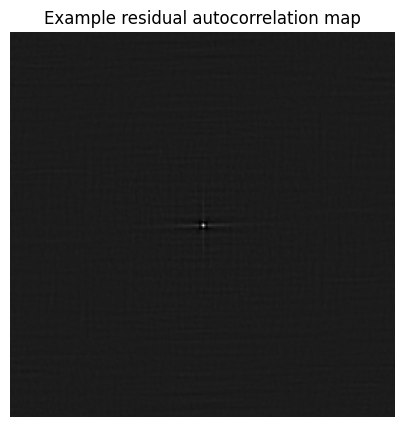

In [6]:
preview_train_rows, preview_ai_rows = build_epoch_train_rows()

train_dataset = ResidualAutocorrelationDataset(preview_train_rows, use_random_crop=True, use_random_flip=True)
val_dataset = ResidualAutocorrelationDataset(val_rows, use_random_crop=False, use_random_flip=False)
test_dataset = ResidualAutocorrelationDataset(test_rows, use_random_crop=False, use_random_flip=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=effective_num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=effective_num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=effective_num_workers)

class_names = ['real', 'ai_generated']

print('Preview epoch training real / ai:', sum(int(row['label_a']) == 0 for row in preview_train_rows), sum(int(row['label_a']) == 1 for row in preview_train_rows))
print('Validation real / ai:', sum(int(row['label_a']) == 0 for row in val_rows), sum(int(row['label_a']) == 1 for row in val_rows))
print('Test real / ai:', sum(int(row['label_a']) == 0 for row in test_rows), sum(int(row['label_a']) == 1 for row in test_rows))
print('Training rows are stored as manifest rows, not precomputed tensors.')
print('DataLoader workers actually in use:', effective_num_workers)

sample_images, sample_labels = next(iter(train_loader))

print('Batch image shape:', sample_images.shape)
print('Batch label shape:', sample_labels.shape)
print('First label:', sample_labels[0].item(), class_names[sample_labels[0].item()])

sample_map = sample_images[0].squeeze(0)
sample_map = sample_map - sample_map.min()
sample_map = sample_map / (sample_map.max() + 1e-6)

plt.figure(figsize=(5, 5))
plt.imshow(sample_map.numpy(), cmap='gray')
plt.title('Example residual autocorrelation map')
plt.axis('off')
plt.show()


## Step 6 - Train the model


For each epoch:
- keep all real training rows
- take the next balanced chunk of AI rows from the shuffled AI pool
- rebuild the training dataset
- shuffle the training batches

That means every epoch is class-balanced, and across many epochs the model gradually sees almost all of the AI pool.


In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

best_val_accuracy = 0.0
best_state = copy.deepcopy(model.state_dict())
history = []
used_train_ai_paths = set()

reset_epoch_sampling()

for epoch in range(epochs):
    train_epoch_rows, train_epoch_ai_rows = build_epoch_train_rows()

    for row in train_epoch_ai_rows:
        used_train_ai_paths.add(row['image_path'])

    train_dataset = ResidualAutocorrelationDataset(train_epoch_rows, use_random_crop=True, use_random_flip=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=effective_num_workers)

    print(
        'Epoch', epoch + 1,
        '| training real / ai =', len(train_real_rows), len(train_epoch_ai_rows),
        '| unique AI seen so far =', len(used_train_ai_paths), 'of', len(train_ai_rows)
    )

    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_total / train_total
    train_accuracy = train_correct / train_total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_total += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch + 1,
            'val_accuracy': val_accuracy,
            'model_state_dict': best_state,
        }, BEST_MODEL_PATH)
        print('Saved new best model at epoch', epoch + 1, 'with validation accuracy', round(val_accuracy, 4))
        print('Saved to:', BEST_MODEL_PATH)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'unique_ai_seen_so_far': len(used_train_ai_paths),
    })

    print(
        'Epoch', epoch + 1,
        '| train loss =', round(train_loss, 4),
        '| train acc =', round(train_accuracy, 4),
        '| val loss =', round(val_loss, 4),
        '| val acc =', round(val_accuracy, 4)
    )

model.load_state_dict(best_state)
print('Best validation accuracy:', round(best_val_accuracy, 4))
print('Final best model path:', BEST_MODEL_PATH)


Epoch 1 | training real / ai = 4837 4837 | unique AI seen so far = 4837 of 24127
Saved new best model at epoch 1 with validation accuracy 0.7249
Saved to: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_all_models_balanced_best.pt
Epoch 1 | train loss = 0.5174 | train acc = 0.7594 | val loss = 0.5822 | val acc = 0.7249
Epoch 2 | training real / ai = 4837 4837 | unique AI seen so far = 9674 of 24127
Saved new best model at epoch 2 with validation accuracy 0.7331
Saved to: /Users/williamwatson/meng_winter_courses/codex/ENSF617-Project/saved_models/srnet_reshuffled_all_models_balanced_best.pt
Epoch 2 | train loss = 0.4877 | train acc = 0.7885 | val loss = 0.5646 | val acc = 0.7331
Epoch 3 | training real / ai = 4837 4837 | unique AI seen so far = 14511 of 24127
Epoch 3 | train loss = 0.4821 | train acc = 0.7842 | val loss = 0.5956 | val acc = 0.7008
Epoch 4 | training real / ai = 4837 4837 | unique AI seen so far = 19348 of 24127
Epoch 4 | trai

## Step 7 - Plot the accuracy and loss for training and validation



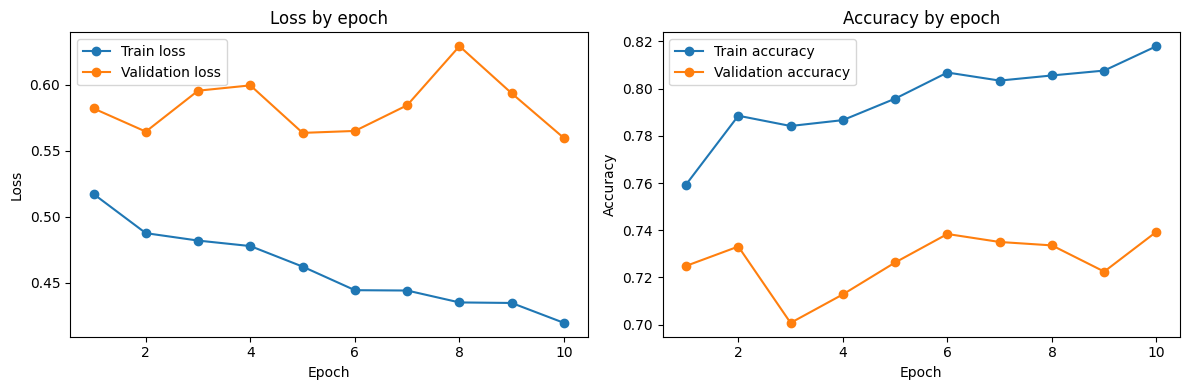

In [8]:
epoch_numbers = [row['epoch'] for row in history]
train_losses = [row['train_loss'] for row in history]
val_losses = [row['val_loss'] for row in history]
train_accuracies = [row['train_accuracy'] for row in history]
val_accuracies = [row['val_accuracy'] for row in history]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, train_losses, marker='o', label='Train loss')
plt.plot(epoch_numbers, val_losses, marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss by epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, train_accuracies, marker='o', label='Train accuracy')
plt.plot(epoch_numbers, val_accuracies, marker='o', label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy by epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Step 8 - Evaluate on the test set once

This cell runs the test set one time and stores all of the final values we need.

That includes:
- overall test loss and test accuracy
- the binary `label_a` confusion matrix
- real recall and AI recall
- per-model AI accuracy for each `label_b` generator


In [ ]:
model.eval()
test_loss_total = 0.0
test_correct = 0
test_total = 0
test_confusion = torch.zeros(2, 2, dtype=torch.int64)
test_correct_by_model = {}
test_total_by_model = {}
test_model_name_map = {
    1: 'SD21',
    2: 'SDXL',
    3: 'SD3',
    4: 'DALLE3',
    5: 'Midjourney',
}
row_index = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        predictions = outputs.argmax(dim=1)
        batch_rows = test_rows[row_index:row_index + labels.size(0)]

        test_loss_total += loss.item() * labels.size(0)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        for row, true_label, predicted_label in zip(batch_rows, labels.cpu(), predictions.cpu()):
            true_value = int(true_label.item())
            predicted_value = int(predicted_label.item())
            test_confusion[true_value, predicted_value] += 1

            if int(row['label_a']) == 1:
                model_label = int(row['label_b'])
                test_total_by_model[model_label] = test_total_by_model.get(model_label, 0) + 1

                if predicted_value == 1:
                    test_correct_by_model[model_label] = test_correct_by_model.get(model_label, 0) + 1
                else:
                    test_correct_by_model.setdefault(model_label, 0)

        row_index += labels.size(0)

test_loss = test_loss_total / test_total
test_accuracy = test_correct / test_total
real_recall = test_confusion[0, 0].item() / test_confusion[0].sum().item()
ai_recall = test_confusion[1, 1].item() / test_confusion[1].sum().item()

test_model_labels = sorted(test_total_by_model)
test_model_names = [f"{model_label} - {test_model_name_map.get(model_label, 'Unknown')}" for model_label in test_model_labels]
test_accuracies = [test_correct_by_model[model_label] / test_total_by_model[model_label] for model_label in test_model_labels]
test_percentages = [accuracy * 100 for accuracy in test_accuracies]

print('Test loss:', round(test_loss, 4))
print('Test accuracy:', round(test_accuracy, 4))
print('Real recall:', round(real_recall, 4))
print('AI recall:', round(ai_recall, 4))


Test loss: 0.5449
Test accuracy: 0.7534
Real recall: 0.7283
AI recall: 0.7784
Stored per-model results for Step 9.


## Step 9 - Plot the final test results

The model is still a binary classifier, so the cleanest final view is:
- a `2 x 2` confusion matrix for `label_a`
- a bar chart showing AI accuracy for each true `label_b` generator on the test set

This cell only uses the values stored in Step 8, so the test set does not need to run again.


Test AI accuracy by label_b:
1 - SD21 | correct / total = 159 / 197 | accuracy = 0.8071
2 - SDXL | correct / total = 162 / 179 | accuracy = 0.905
3 - SD3 | correct / total = 195 / 230 | accuracy = 0.8478
4 - DALLE3 | correct / total = 86 / 215 | accuracy = 0.4
5 - Midjourney | correct / total = 206 / 217 | accuracy = 0.9493


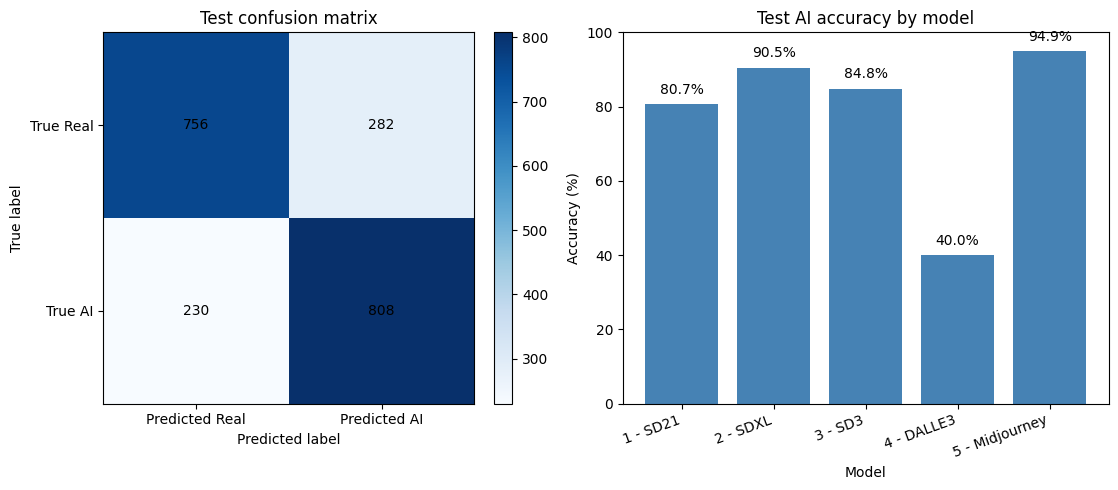

In [24]:
print('Test AI accuracy by label_b:')
for model_label, model_name, accuracy in zip(test_model_labels, test_model_names, test_accuracies):
    total = test_total_by_model[model_label]
    correct = test_correct_by_model[model_label]
    print(model_name, '| correct / total =', correct, '/', total, '| accuracy =', round(accuracy, 4))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
confusion_array = test_confusion.numpy()
plt.imshow(confusion_array, cmap='Blues')
plt.xticks([0, 1], ['Predicted Real', 'Predicted AI'])
plt.yticks([0, 1], ['True Real', 'True AI'])
plt.title('Test confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')

for row_index in range(2):
    for column_index in range(2):
        value = confusion_array[row_index, column_index]
        plt.text(column_index, row_index, str(value), ha='center', va='center', color='black')

plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
bar_positions = list(range(len(test_model_labels)))
plt.bar(bar_positions, test_percentages, color='steelblue')
plt.xticks(bar_positions, test_model_names, rotation=20, ha='right')
plt.ylim(0, 100)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Test AI accuracy by model')

for position, percentage in zip(bar_positions, test_percentages):
    plt.text(position, min(percentage + 2, 98), f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Discussion

We can see from the confusion matrix that the model performs reasonably well (74% accuracy) on the test set, and there is minimal class bias. Interestingly, when we inspect the performance of the model on each model individually, we can see that 4 of the 5 models are detected quite accurately (ranging from 80% to 95%), while DALLE3 performs quiet poorly. This is something worth investigating in the future. Midjourney is surprisingly accurate at 95%.